# Hotel Booking Cancellation Prediction
## Revenue Management with Machine Learning Classification

**Author:** Group 1 MiBA

**Subject:** Artificial Intelligence II


**Dataset:** Hotel Booking Demand — Antonio, Almeida & Nunes (2019), *Data in Brief*, Vol. 22  
**Kaggle Source:** https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand  

---

### Objective
Binary classification task: predict whether a hotel booking will be **cancelled (1)** or **not (0)** using 119,390 bookings across two hotel types (City Hotel, Resort Hotel).

## 1. Setup & Imports

In [353]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

from scipy.stats import randint, uniform



print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading

Read the full hotel bookings CSV into a pandas DataFrame (119,390 rows). We print shape and the overall cancellation rate as a first sanity check before any transformation.

In [354]:
df = pd.read_csv('hotel_bookings.csv')
print(f'Dataset shape: {df.shape}')
print(f'Overall cancellation rate: {df["is_canceled"].mean()*100:.1f}%')
print(f'\nColumn names:')
print(df.columns.tolist())
print(df.head())

Dataset shape: (119390, 32)
Overall cancellation rate: 37.0%

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015    

## 3. Feature Engineering

Transform the raw dataset into model-ready inputs:
1. **Drop leakage columns** — `reservation_status` and `reservation_status_date` are only populated *after* a booking resolves, so they cannot exist at prediction time.
2. **Handle missing values** — `agent`/`company` NaN → 0 (meaningful: no agent/company). Drop the 4 rows where `children` is null.
3. **Encode categoricals** — rare countries grouped as "Other"; one-hot encode all nominal columns.
4. **Ordinal-encode months** — map month names to 1–12.

In [355]:
# Work on a copy
data = df.copy()

# --- Fix 1: Data leakage columns ---
# reservation_status mirrors is_canceled; reservation_status_date is post-event
data.drop(columns=['reservation_status', 'reservation_status_date', 'assigned_room_type'], inplace=True)
print('Dropped leakage columns: reservation_status, reservation_status_date, and assigned_room_type')


# --- Drop rows with null 'children' and staff rooms (Type P) ---
n_before = len(data)
data.dropna(subset=['children'], inplace=True)
data = data[data['reserved_room_type'] != 'P']
print(f'Dropped {n_before - len(data)} rows (null children + Type P complimentary rooms)')


# --- Fix 2: Fill agent/company NaN with 0 ---
# 0 means 'no agent' / 'no company' — a meaningful distinction
data['agent']   = data['agent'].fillna(0)
data['company'] = data['company'].fillna(0)
print('Filled agent/company NaN with 0')

# --- Fix 3a: Top 20 countries + Others  ---
top_countries = data['country'].value_counts().nlargest(20).index
data['country'] = data['country'].apply(lambda x: x if x in top_countries else 'Other')
data['country'] = data['country'].fillna('Unknown')
print(f'Country grouped to top 20 + Other')

# --- Fix 3b: Ordinal encode room type (alphabetical = assumed quality order, anonymized in dataset) ---
# Higher number = higher tier room. P (complimentary) already dropped above.
room_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'L': 9}
data['reserved_room_type'] = data['reserved_room_type'].map(room_map)
print(f'Ordinal encoded reserved_room_type: {room_map}')

# --- Fix 3c: One-hot encode remaining nominal categorical columns ---
nominal_cols = [
    'hotel', 'meal', 'country', 'market_segment', 'distribution_channel',
    'deposit_type', 'customer_type'
]
data = pd.get_dummies(data, columns=nominal_cols, drop_first=False)
print(f'One-hot encoded {len(nominal_cols)} nominal columns')

# Ordinal encode month (January=1 ... December=12)
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
data['arrival_date_month'] = data['arrival_date_month'].map(month_map)

print(f'\nFinal dataset shape: {data.shape}')
print(f'Features: {data.shape[1] - 1} (after encoding)')

Dropped leakage columns: reservation_status, reservation_status_date, and assigned_room_type
Dropped 16 rows (null children + Type P complimentary rooms)
Filled agent/company NaN with 0
Country grouped to top 20 + Other
Ordinal encoded reserved_room_type: {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'L': 9}
One-hot encoded 7 nominal columns

Final dataset shape: (119374, 69)
Features: 68 (after encoding)


### Train / Test Split

Split 80/20 using stratified sampling so the cancellation rate is identical in both partitions. The **test set is held out** and never seen during model training or hyperparameter search.

In [356]:
# --- Train/test split ---
X = data.drop(columns=['is_canceled'])
y = data['is_canceled']

# Verify no leakage columns remain
leakage_cols = [c for c in X.columns if 'reservation_status' in c]
assert len(leakage_cols) == 0, f'Leakage columns still present: {leakage_cols}'
print('Leakage check passed — reservation_status not in feature set.')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'\nTrain set: {X_train.shape[0]:,} samples')
print(f'Test  set: {X_test.shape[0]:,} samples')
print(f'Train cancellation rate: {y_train.mean()*100:.1f}%')
print(f'Test  cancellation rate: {y_test.mean()*100:.1f}%')

Leakage check passed — reservation_status not in feature set.

Train set: 89,530 samples
Test  set: 29,844 samples
Train cancellation rate: 37.0%
Test  cancellation rate: 37.0%


### Feature Scaling

Fit `StandardScaler` **only on the training set**, then apply the fitted transform to the test set. Fitting on the full dataset before splitting would leak test-set distribution information into the scaler — a subtle but real form of data leakage.

In [357]:
# --- Standard scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('StandardScaler applied (fit on training data only).')

StandardScaler applied (fit on training data only).


## 4. Exploratory Data Analysis



### Column Data Types



In [358]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

### Data Preview


In [359]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Missing Value Analysis

Confirm all missing values have been handled. Any remaining NaNs would cause silent errors or bias in downstream models.

In [360]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
print(missing_df)

Columns with missing values:
          Missing Count  Missing %
company          112593      94.31
agent             16340      13.69
country             488       0.41
children              4       0.00


### Class Balance

Check the ratio of cancelled vs. not-cancelled bookings. The two hotel types may differ in cancellation rates, which affects how we interpret precision and recall.

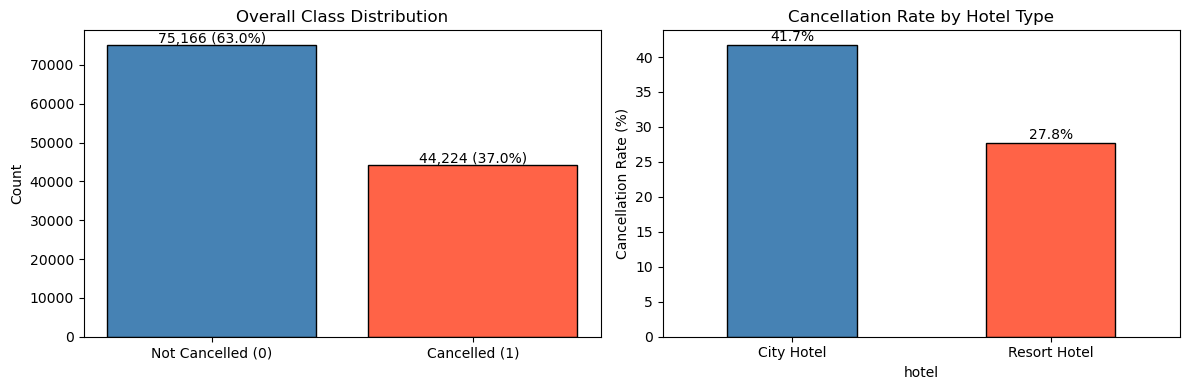


Overall cancellation rate: 37.0%


In [361]:
# Class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cancel_counts = df['is_canceled'].value_counts()
axes[0].bar(['Not Cancelled (0)', 'Cancelled (1)'], cancel_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Overall Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(cancel_counts.values):
    axes[0].text(i, v + 500, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center')

cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
cancel_by_hotel.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Cancellation Rate by Hotel Type')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xticklabels(cancel_by_hotel.index, rotation=0)
for i, v in enumerate(cancel_by_hotel.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()
print(f'\nOverall cancellation rate: {df["is_canceled"].mean()*100:.1f}%')

### Feature Distributions

Visualize the distribution of key numeric features split by cancellation outcome. Features where the two distributions diverge significantly are strong candidates for discriminative predictors.

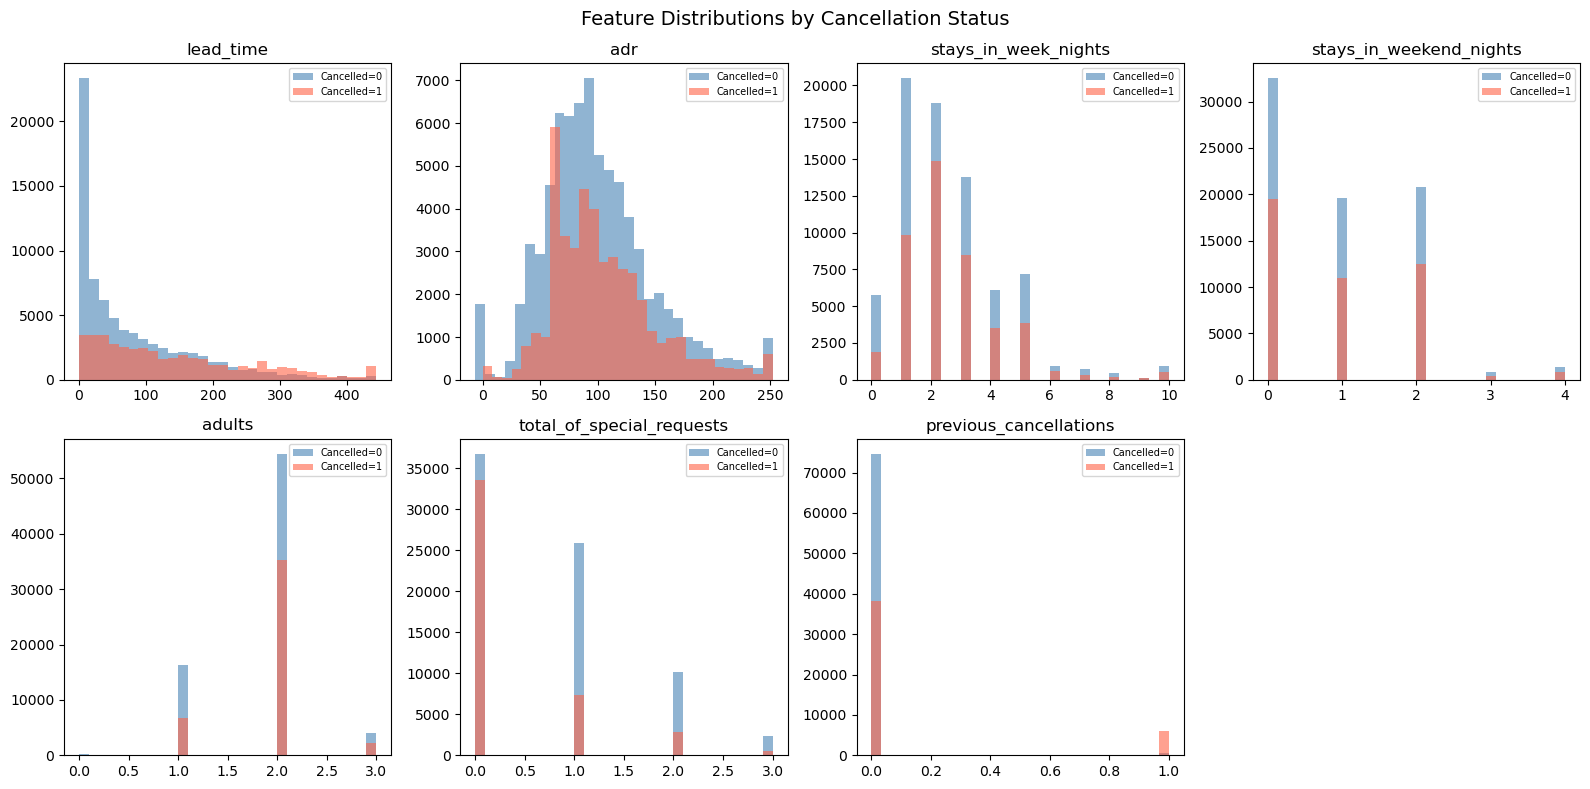

In [362]:
# Distributions of key numeric features
numeric_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
                'adults', 'total_of_special_requests', 'previous_cancellations']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        axes[i].hist(df[df['is_canceled'] == label][col].clip(upper=df[col].quantile(0.99)),
                     bins=30, alpha=0.6, color=color,
                     label=f'Cancelled={label}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

axes[-1].axis('off')
plt.suptitle('Feature Distributions by Cancellation Status', fontsize=14)
plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)

Fit a Random Forest on **training data only** to rank features by average impurity reduction

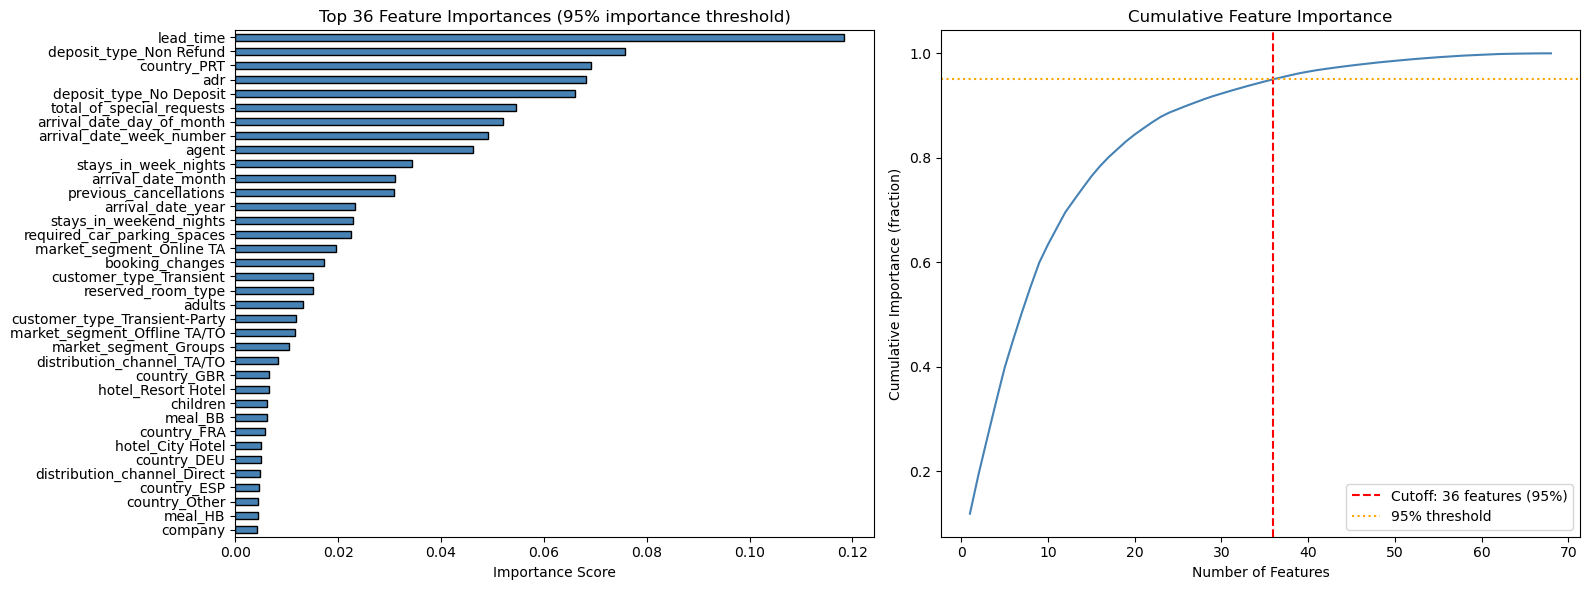

Keeping 36 features (95% cumulative importance threshold)
lead_time                        0.118363
deposit_type_Non Refund          0.075818
country_PRT                      0.069189
adr                              0.068267
deposit_type_No Deposit          0.066040
total_of_special_requests        0.054538
arrival_date_day_of_month        0.051984
arrival_date_week_number         0.049098
agent                            0.046152
stays_in_week_nights             0.034414
arrival_date_month               0.030997
previous_cancellations           0.030871
arrival_date_year                0.023261
stays_in_weekend_nights          0.022942
required_car_parking_spaces      0.022395
market_segment_Online TA         0.019644
booking_changes                  0.017324
customer_type_Transient          0.015072
reserved_room_type               0.015047
adults                           0.013124
customer_type_Transient-Party    0.011794
market_segment_Offline TA/TO     0.011509
market_segment_Gro

In [363]:
# Fit Random Forest on training data only
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_imp.fit(X_train, y_train)

feat_imp = pd.Series(rf_imp.feature_importances_, index=X_train.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=False)

# --- Feature selection: keep features that explain 95% of total importance ---
cumulative = feat_imp_sorted.cumsum() / feat_imp_sorted.sum()
n_features = int((cumulative < 0.95).sum()) + 1  # first index where cumulative >= 95%
n_features = max(n_features, 10)                 # keep at least 10
top_features = feat_imp_sorted.head(n_features)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_features.sort_values().plot(kind="barh", color="steelblue", edgecolor="black", ax=axes[0])
axes[0].set_title(f"Top {n_features} Feature Importances (95% importance threshold)", fontsize=12)
axes[0].set_xlabel("Importance Score")

axes[1].plot(range(1, len(feat_imp_sorted) + 1), cumulative.values, color="steelblue")
axes[1].axvline(n_features, color="red", linestyle="--", label=f"Cutoff: {n_features} features (95%)")
axes[1].axhline(0.95, color="orange", linestyle=":", label="95% threshold")
axes[1].set_xlabel("Number of Features")
axes[1].set_ylabel("Cumulative Importance (fraction)")
axes[1].set_title("Cumulative Feature Importance")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Keeping {n_features} features (95% cumulative importance threshold)")
print(top_features.to_string())

# --- Force hotel type in ---
selected_features = top_features.index.tolist()
if "hotel_City Hotel" not in selected_features:
    selected_features.append("hotel_City Hotel")

X_train = X_train[selected_features]
X_test  = X_test[selected_features]
X       = X[selected_features]

# Re-fit scaler on the reduced training set (fit on train only)
scaler_sel = StandardScaler()
X_train_scaled = scaler_sel.fit_transform(X_train)
X_test_scaled  = scaler_sel.transform(X_test)

print(f"Final feature set ({len(selected_features)} features):")
print(selected_features)
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")


## 5. Multi-Model Analysis

Train seven classifiers spanning the range of methods covered in lectures on the same train/test split. For each model we record accuracy, precision, recall, F1, train AUC, test AUC, and the **Train–Test AUC gap** as an overfitting indicator.

Models:
1. Logistic Regression (linear baseline — S1)
2. Random Forest (bagging + random feature subsets — S2)
3. XGBoost (gradient boosting — S2 extension)
4. LightGBM (gradient boosting, leaf-wise growth)
5. Neural Network / MLP (multi-layer perceptron — S5/S6)
6. Ensemble – Soft Voting (LR + RF + XGB + LightGBM)

### Evaluation Helper

`evaluate_model()` trains a model, generates predictions on the held-out test set, computes all metrics, and flags overfitting when Train–Test AUC gap > 0.05. Results are stored in shared dictionaries for later aggregation.

In [364]:
# Helper function to evaluate a model and check for overfitting
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred    = model.predict(X_te)
    y_prob    = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    y_prob_tr = model.predict_proba(X_tr)[:, 1] if hasattr(model, 'predict_proba') else None

    train_auc = roc_auc_score(y_tr, y_prob_tr) if y_prob_tr is not None else np.nan
    test_auc  = roc_auc_score(y_te, y_prob)    if y_prob    is not None else np.nan
    gap       = train_auc - test_auc
    flag      = '⚠️  OVERFITTING' if gap > 0.05 else ('~ mild' if gap > 0.02 else '✓ OK')

    print(f"  Overfitting check — Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f} | Gap: {gap:.4f}  {flag}")

    results = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall':    recall_score(y_te, y_pred),
        'F1':        f1_score(y_te, y_pred),
        'Train AUC': train_auc,
        'AUC':       test_auc,
        'AUC Gap':   gap,
    }
    return results, model, y_prob

all_results    = []
roc_data       = {}
trained_models = {}
print('Evaluation helper ready.')

Evaluation helper ready.


### 5.1 Logistic Regression (Baseline)

A simple, fully interpretable linear model. Serves as the performance floor — any more complex model that fails to beat this is not worth the additional cost. Requires feature scaling.

In [365]:
# --- 5.1 Logistic Regression (baseline) ---
lr = LogisticRegression(max_iter=1000, random_state=42)
r, m, p = evaluate_model('Logistic Regression', lr, X_train_scaled, X_test_scaled, y_train, y_test)
all_results.append(r)
trained_models['Logistic Regression'] = m
roc_data['Logistic Regression'] = (y_test, p)

print(f"Logistic Regression  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
print(classification_report(y_test, m.predict(X_test_scaled), target_names=['Not Cancelled', 'Cancelled']))

  Overfitting check — Train AUC: 0.8824 | Test AUC: 0.8797 | Gap: 0.0027  ✓ OK
Logistic Regression  |  Acc: 0.8016  Prec: 0.7954  Rec: 0.6249  F1: 0.6999  AUC: 0.8797
               precision    recall  f1-score   support

Not Cancelled       0.80      0.91      0.85     18792
    Cancelled       0.80      0.62      0.70     11052

     accuracy                           0.80     29844
    macro avg       0.80      0.77      0.78     29844
 weighted avg       0.80      0.80      0.80     29844



### 5.2 Random Forest (Tuned)

An ensemble of decision trees trained on bootstrap samples with random feature subsets at each split. Tuned with `RandomizedSearchCV` (20 iterations, 3-fold CV) over tree depth, number of estimators, and minimum samples per leaf.

In [366]:
# --- 5.2 Random Forest (tuned via RandomizedSearchCV) ---
# max_features='sqrt' is fixed 
# The search covers structural parameters only: tree depth and leaf constraints
rf_param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf':  randint(1, 5),
}
rf_base = RandomForestClassifier(
    max_features='sqrt', 
    criterion='entropy',
    random_state=42,
    n_jobs=-1
)
rf_search = RandomizedSearchCV(rf_base, rf_param_dist, n_iter=20,
                               cv=3, scoring='roc_auc',
                               random_state=42, n_jobs=-1, verbose=0)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print(f'Best RF params: {rf_search.best_params_}')

r, m, p = evaluate_model('Random Forest', best_rf, X_train, X_test, y_train, y_test)
all_results.append(r)
trained_models['Random Forest'] = m
roc_data['Random Forest'] = (y_test, p)

print(f"\nRandom Forest  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
print(classification_report(y_test, m.predict(X_test), target_names=['Not Cancelled', 'Cancelled']))


Best RF params: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
  Overfitting check — Train AUC: 0.9975 | Test AUC: 0.9585 | Gap: 0.0390  ~ mild

Random Forest  |  Acc: 0.8889  Prec: 0.8776  Rec: 0.8135  F1: 0.8443  AUC: 0.9585
               precision    recall  f1-score   support

Not Cancelled       0.89      0.93      0.91     18792
    Cancelled       0.88      0.81      0.84     11052

     accuracy                           0.89     29844
    macro avg       0.89      0.87      0.88     29844
 weighted avg       0.89      0.89      0.89     29844



### 5.3 XGBoost (Tuned)

Gradient boosted trees where each new tree corrects the residuals of the previous ensemble. Regularised via L2 penalty and subsampling. Tuned with `RandomizedSearchCV` over learning rate, depth, subsampling ratios, and regularisation strength.

In [367]:
# --- 5.3 XGBoost (tuned) ---
xgb_param_dist = {
    'n_estimators':     randint(100, 400),
    'max_depth':        randint(3, 8),
    'learning_rate':    uniform(0.01, 0.3),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 6),
    'gamma':            uniform(0, 0.5),
}
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss',
                         use_label_encoder=False, n_jobs=-1, verbosity=0)
xgb_search = RandomizedSearchCV(xgb_base, xgb_param_dist, n_iter=20,
                                cv=3, scoring='roc_auc',
                                random_state=42, n_jobs=-1, verbose=0)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print(f'Best XGBoost params: {xgb_search.best_params_}')

r, m, p = evaluate_model('XGBoost', best_xgb, X_train, X_test, y_train, y_test)
all_results.append(r)
trained_models['XGBoost'] = m
roc_data['XGBoost'] = (y_test, p)

print(f"\nXGBoost  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
print(classification_report(y_test, m.predict(X_test), target_names=['Not Cancelled', 'Cancelled']))

Best XGBoost params: {'colsample_bytree': 0.6092249700165663, 'gamma': 0.2623873301291946, 'learning_rate': 0.12995829151457663, 'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 370, 'subsample': 0.7824279936868144}
  Overfitting check — Train AUC: 0.9706 | Test AUC: 0.9528 | Gap: 0.0178  ✓ OK

XGBoost  |  Acc: 0.8779  Prec: 0.8536  Rec: 0.8092  F1: 0.8308  AUC: 0.9528
               precision    recall  f1-score   support

Not Cancelled       0.89      0.92      0.90     18792
    Cancelled       0.85      0.81      0.83     11052

     accuracy                           0.88     29844
    macro avg       0.87      0.86      0.87     29844
 weighted avg       0.88      0.88      0.88     29844



### 5.4 LightGBM

Microsoft's gradient boosting framework. Grows trees leaf-wise rather than level-wise, which is faster and often more accurate on large tabular datasets. Uses fixed high-quality defaults — no tuning required.

In [368]:
# --- 5.4 LightGBM (new model) ---
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

r, m, p = evaluate_model('LightGBM', lgbm, X_train, X_test, y_train, y_test)
all_results.append(r)
trained_models['LightGBM'] = m
roc_data['LightGBM'] = (y_test, p)

print(f"LightGBM  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
print(classification_report(y_test, m.predict(X_test), target_names=['Not Cancelled', 'Cancelled']))

  Overfitting check — Train AUC: 0.9621 | Test AUC: 0.9506 | Gap: 0.0116  ✓ OK
LightGBM  |  Acc: 0.8763  Prec: 0.8585  Rec: 0.7973  F1: 0.8268  AUC: 0.9506
               precision    recall  f1-score   support

Not Cancelled       0.89      0.92      0.90     18792
    Cancelled       0.86      0.80      0.83     11052

     accuracy                           0.88     29844
    macro avg       0.87      0.86      0.87     29844
 weighted avg       0.88      0.88      0.88     29844



### 5.5 Neural Network (MLP)

A multi-layer perceptron with two hidden layers (128 → 64 units) and ReLU activations, as covered in S5/S6. MLP is sensitive to feature magnitudes so it uses the **scaled** feature set. L2 regularization (`alpha`) penalises large weights — equivalent to Ridge regularization from S6 — to reduce the risk of overfitting given the large number of parameters. Early stopping monitors a held-out 10% of training data and halts training when validation loss stops improving.

In [369]:
# --- 5.5 Neural Network (MLP) ---
# Architecture: two hidden layers (128, 64) with ReLU activation
# alpha: L2 regularization (Ridge penalty on weights) to reduce overfitting (S6)
# Early stopping: holds out 10% of training data to detect when val loss plateaus
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
)

r, m, p = evaluate_model('Neural Network (MLP)', mlp, X_train_scaled, X_test_scaled, y_train, y_test)
all_results.append(r)
trained_models['Neural Network (MLP)'] = m
roc_data['Neural Network (MLP)'] = (y_test, p)

print(f"MLP  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
print(classification_report(y_test, m.predict(X_test_scaled), target_names=['Not Cancelled', 'Cancelled']))

  Overfitting check — Train AUC: 0.9534 | Test AUC: 0.9387 | Gap: 0.0147  ✓ OK
MLP  |  Acc: 0.8637  Prec: 0.8304  Rec: 0.7940  F1: 0.8118  AUC: 0.9387
               precision    recall  f1-score   support

Not Cancelled       0.88      0.90      0.89     18792
    Cancelled       0.83      0.79      0.81     11052

     accuracy                           0.86     29844
    macro avg       0.86      0.85      0.85     29844
 weighted avg       0.86      0.86      0.86     29844



### 5.6 Ensemble — Soft Voting Classifier

Combines LR, RF, XGBoost, and LightGBM via soft (probability-weighted) voting. Diversity between a linear model and three tree-based models reduces variance and often improves generalisation beyond any single learner. LR is wrapped in a pipeline so it receives scaled features.

In [370]:
# --- 5.7 Ensemble — VotingClassifier (LR + RF + XGB + LGBM) ---
# Implements the majority voting approach described (but never built) in the original notebooks.
# Tree-based models use unscaled features; LR and MLP use pipelines with scaler

lr_pipe  = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=42))])

ensemble = VotingClassifier(
    estimators=[
        ('lr',    lr_pipe),
        ('rf',    RandomForestClassifier(n_estimators=200, criterion='entropy',
                                         random_state=42, n_jobs=-1)),
        ('xgb',  XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                random_state=42, eval_metric='logloss',
                                use_label_encoder=False, n_jobs=-1, verbosity=0)),
        ('lgbm', LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                 random_state=42, n_jobs=-1, verbose=-1)),
    ],
    voting='soft'  # soft voting uses predicted probabilities for better calibration
)

r, m, p = evaluate_model('Ensemble (Soft Vote)', ensemble, X_train, X_test, y_train, y_test)
all_results.append(r)
trained_models['Ensemble'] = m
roc_data['Ensemble (Soft Vote)'] = (y_test, p)

print(f"Ensemble  |  Acc: {r['Accuracy']:.4f}  Prec: {r['Precision']:.4f}  Rec: {r['Recall']:.4f}  F1: {r['F1']:.4f}  AUC: {r['AUC']:.4f}")
print(classification_report(y_test, m.predict(X_test), target_names=['Not Cancelled', 'Cancelled']))

  Overfitting check — Train AUC: 0.9828 | Test AUC: 0.9510 | Gap: 0.0317  ~ mild
Ensemble  |  Acc: 0.8777  Prec: 0.8748  Rec: 0.7815  F1: 0.8255  AUC: 0.9510
               precision    recall  f1-score   support

Not Cancelled       0.88      0.93      0.91     18792
    Cancelled       0.87      0.78      0.83     11052

     accuracy                           0.88     29844
    macro avg       0.88      0.86      0.87     29844
 weighted avg       0.88      0.88      0.88     29844



## 6. Model Metrics Across All Models

Evaluate and visualise every model side-by-side: ROC curves, confusion matrices, 5-fold cross-validation, and a ranked summary table.

### ROC Curves

Plot the Receiver Operating Characteristic curve for every model on a single axis. AUC summarises discrimination power across all decision thresholds — 1.0 is perfect, 0.5 is equivalent to random guessing.

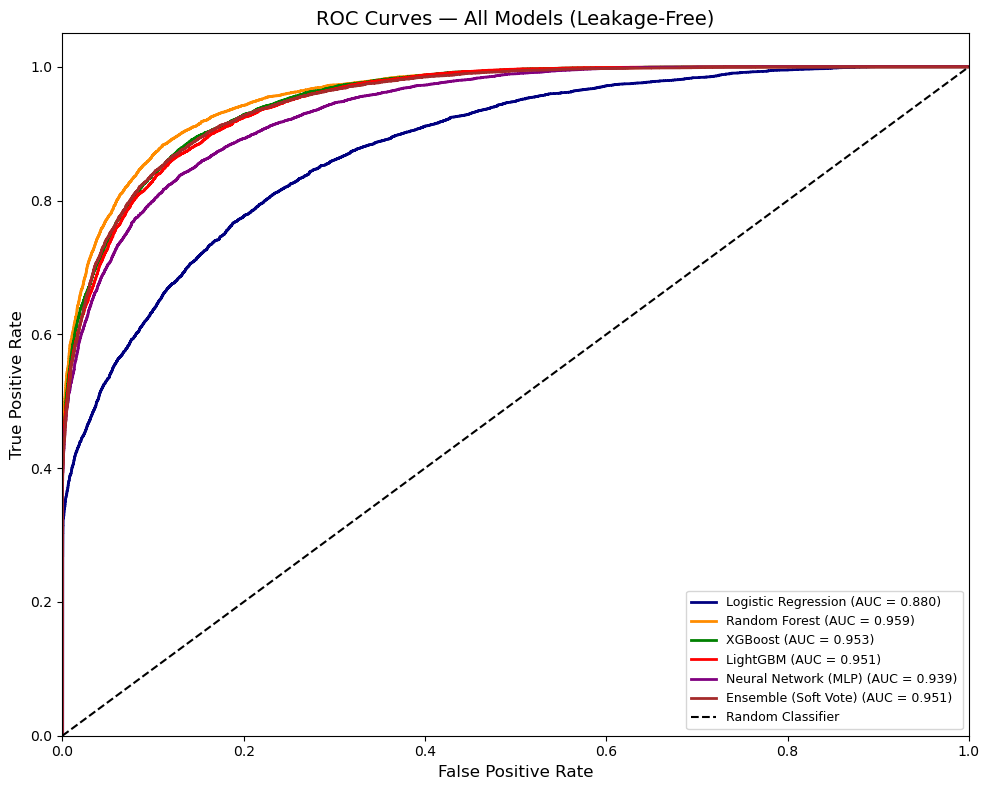

In [371]:
# --- ROC Curves — all models on one plot ---
plt.figure(figsize=(10, 8))

colors = ['navy', 'darkorange', 'green', 'red', 'purple', 'brown', 'deeppink']
for i, (name, (y_t, y_p)) in enumerate(roc_data.items()):
    if y_p is not None:
        fpr, tpr, _ = roc_curve(y_t, y_p)
        auc = roc_auc_score(y_t, y_p)
        plt.plot(fpr, tpr, color=colors[i % len(colors)],
                 lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models (Leakage-Free)', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### Confusion Matrices

For the top four models, show the breakdown of True Positives, False Positives, True Negatives, and False Negatives. This reveals the precision–recall trade-off in concrete counts: false positives risk overbooking; false negatives mean empty rooms from undetected cancellations.

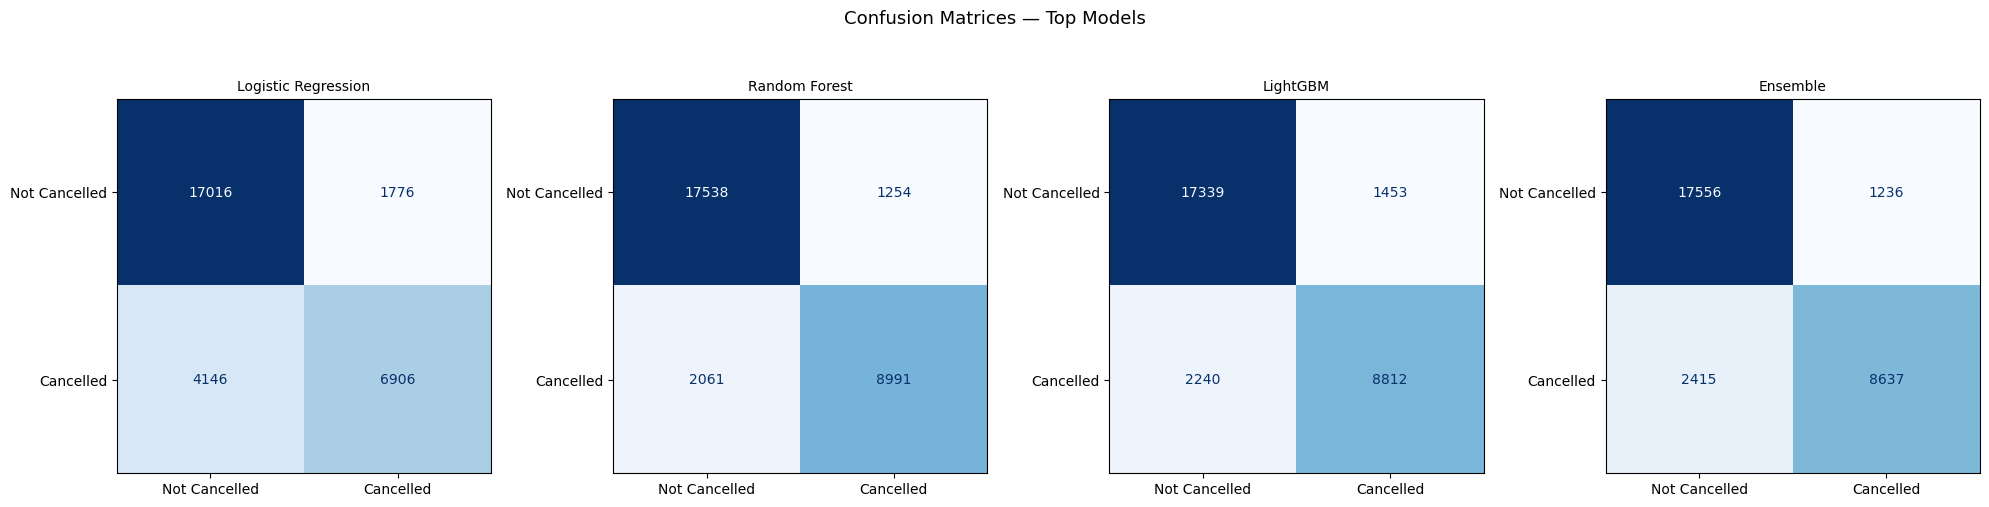

In [372]:
# --- Confusion Matrices for top models ---
top_model_keys = ['Logistic Regression', 'Random Forest', 'LightGBM', 'Ensemble']
top_model_X = {
    'Logistic Regression': X_test_scaled,
    'Random Forest': X_test,
    'LightGBM': X_test,
    'Ensemble': X_test,
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, top_model_keys):
    model = trained_models[name]
    X_eval = top_model_X[name]
    cm = confusion_matrix(y_test, model.predict(X_eval))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Cancelled', 'Cancelled'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Confusion Matrices — Top Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Threshold Selection

The default decision threshold of 0.5 is rarely the optimal operating point. Threshold selection is part of proper evaluation and **must be done on a validation set — never on the test set**.

For hotel cancellations, the two error types carry different business costs:
- **False Positive** (predict cancellation, guest shows up) → hotel oversells, guest may be denied a room — reputational damage
- **False Negative** (miss a cancellation) → empty room, lost revenue

The F1-maximising threshold is identified on a held-out 20% of the training data, then the best model is re-evaluated at that threshold on the test set. A hotel prioritising precision (avoiding overbooking) should raise the threshold; one focused on revenue recovery should lower it.

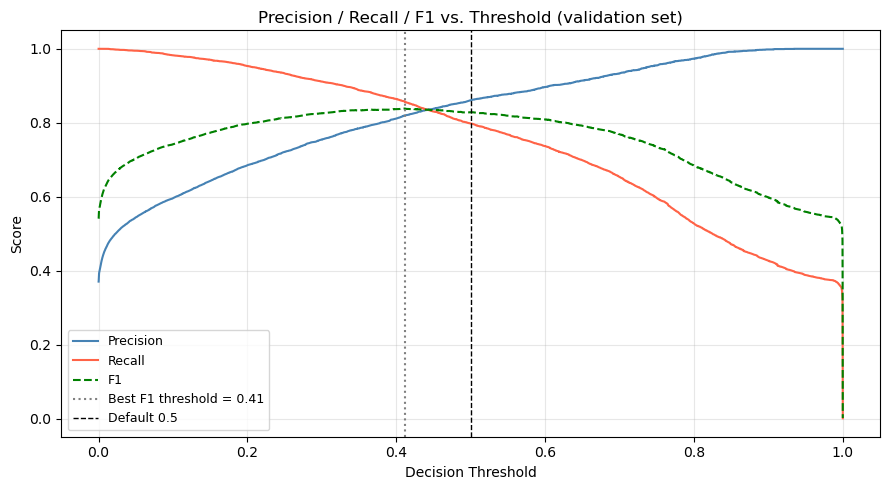

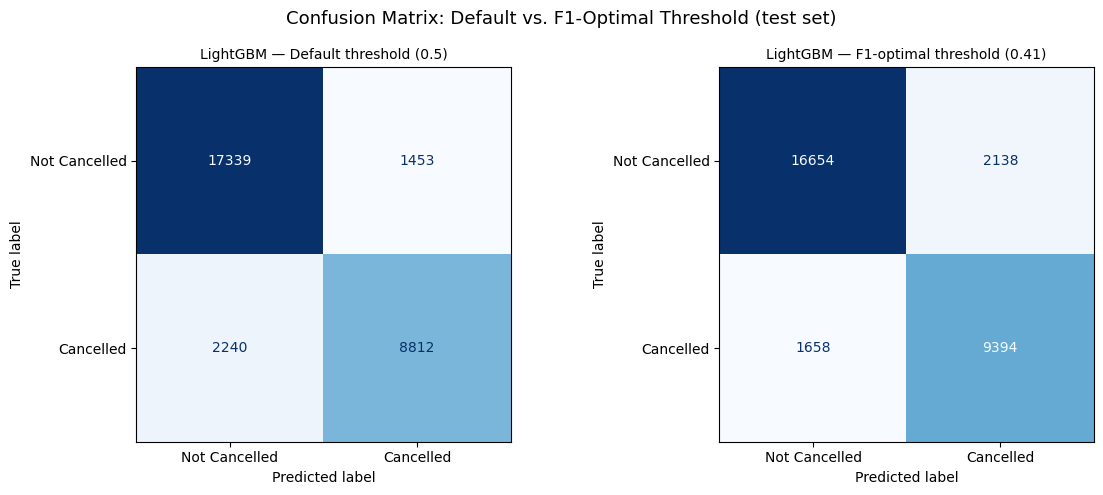

Threshold selected on validation set: 0.41

Metrics at optimised threshold 0.41 (test set):
               precision    recall  f1-score   support

Not Cancelled       0.91      0.89      0.90     18792
    Cancelled       0.81      0.85      0.83     11052

     accuracy                           0.87     29844
    macro avg       0.86      0.87      0.86     29844
 weighted avg       0.87      0.87      0.87     29844



In [373]:
# --- Threshold Selection on Validation Set (never on X_test) ---
# Hold out 20% of training data purely for threshold selection
X_tr_t, X_val_t, y_tr_t, y_val_t = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

lgbm_t = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=8, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1
)
lgbm_t.fit(X_tr_t, y_tr_t)
val_probs = lgbm_t.predict_proba(X_val_t)[:, 1]

# Precision, recall, F1 across thresholds
precision_vals, recall_vals, thresh_vals = precision_recall_curve(y_val_t, val_probs)
f1_vals = (2 * precision_vals[:-1] * recall_vals[:-1]
           / (precision_vals[:-1] + recall_vals[:-1] + 1e-9))
best_idx = np.argmax(f1_vals)
best_threshold = float(thresh_vals[best_idx])

# Plot: metrics vs threshold
plt.figure(figsize=(9, 5))
plt.plot(thresh_vals, precision_vals[:-1], label='Precision', color='steelblue')
plt.plot(thresh_vals, recall_vals[:-1],    label='Recall',    color='tomato')
plt.plot(thresh_vals, f1_vals,             label='F1',        color='green', linestyle='--')
plt.axvline(best_threshold, color='gray',  linestyle=':',  linewidth=1.5,
            label=f'Best F1 threshold = {best_threshold:.2f}')
plt.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Default 0.5')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs. Threshold (validation set)', fontsize=12)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrices: default vs optimal threshold (on test set)
test_probs = trained_models['LightGBM'].predict_proba(X_test)[:, 1]
fig, axes  = plt.subplots(1, 2, figsize=(12, 5))
for ax, (threshold, label) in zip(axes, [
    (0.5,            'Default threshold (0.5)'),
    (best_threshold, f'F1-optimal threshold ({best_threshold:.2f})'),
]):
    preds = (test_probs >= threshold).astype(int)
    cm    = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Not Cancelled', 'Cancelled']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'LightGBM — {label}', fontsize=10)
plt.suptitle('Confusion Matrix: Default vs. F1-Optimal Threshold (test set)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Threshold selected on validation set: {best_threshold:.2f}')
print(f'\nMetrics at optimised threshold {best_threshold:.2f} (test set):')
preds_opt = (test_probs >= best_threshold).astype(int)
print(classification_report(y_test, preds_opt, target_names=['Not Cancelled', 'Cancelled']))

### Stratified K-Fold Cross-Validation

5-fold stratified CV on the full feature set gives a more robust AUC estimate than a single split. Mean ± std across folds captures both model quality and stability — high variance across folds flags sensitivity to the data partition.

In [374]:
# 5-fold stratified CV for key models (using full dataset X, y)
# Tree models use raw features; LR and MLP use pipelines with StandardScaler
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
                                      ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    'Random Forest':  RandomForestClassifier(n_estimators=200, criterion='entropy',
                                              random_state=42, n_jobs=-1),
    'XGBoost':        XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                     random_state=42, eval_metric='logloss',
                                     use_label_encoder=False, n_jobs=-1, verbosity=0),
    'LightGBM':       LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                      random_state=42, n_jobs=-1, verbose=-1),
    'Neural Network (MLP)': Pipeline([('scaler', StandardScaler()),
                                       ('mlp', MLPClassifier(hidden_layer_sizes=(128, 64),
                                                             activation='relu', alpha=0.001,
                                                             max_iter=200,
                                                             random_state=42))]),
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25}  CV AUC: {scores.mean():.4f} ± {scores.std():.4f}  (folds: {np.round(scores, 4)})')


Logistic Regression        CV AUC: 0.8814 ± 0.0012  (folds: [0.8797 0.8806 0.8814 0.8825 0.8829])
Random Forest              CV AUC: 0.9605 ± 0.0007  (folds: [0.9606 0.9616 0.9598 0.961  0.9597])
XGBoost                    CV AUC: 0.9439 ± 0.0004  (folds: [0.944  0.9437 0.944  0.9446 0.9433])
LightGBM                   CV AUC: 0.9470 ± 0.0006  (folds: [0.9467 0.9471 0.9478 0.9475 0.9461])
Neural Network (MLP)       CV AUC: 0.9323 ± 0.0015  (folds: [0.9319 0.9344 0.9307 0.9336 0.9307])


### Summary Results Table

Aggregate all metrics — accuracy, precision, recall, F1, train AUC, test AUC, AUC gap, and 5-fold CV AUC — ranked by test AUC descending. This is the definitive leakage-free model comparison.

In [375]:
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.round(4)

# Add CV AUC for models that have it
results_df['CV AUC (5-fold)'] = np.nan
for name, scores in cv_results.items():
    if name in results_df.index:
        results_df.loc[name, 'CV AUC (5-fold)'] = round(scores.mean(), 4)

results_df = results_df.sort_values('AUC', ascending=False)

print('='*75)
print('MODEL PERFORMANCE SUMMARY')
print('='*75)
print(results_df.to_string())
print('='*75)


MODEL PERFORMANCE SUMMARY
                      Accuracy  Precision  Recall      F1  Train AUC     AUC  AUC Gap  CV AUC (5-fold)
Model                                                                                                 
Random Forest           0.8889     0.8776  0.8135  0.8443     0.9975  0.9585   0.0390           0.9605
XGBoost                 0.8779     0.8536  0.8092  0.8308     0.9706  0.9528   0.0178           0.9439
Ensemble (Soft Vote)    0.8777     0.8748  0.7815  0.8255     0.9828  0.9510   0.0317              NaN
LightGBM                0.8763     0.8585  0.7973  0.8268     0.9621  0.9506   0.0116           0.9470
Neural Network (MLP)    0.8637     0.8304  0.7940  0.8118     0.9534  0.9387   0.0147           0.9323
Logistic Regression     0.8016     0.7954  0.6249  0.6999     0.8824  0.8797   0.0027           0.8814


### Metric Comparison Bar Chart

Side-by-side bar chart comparing all models across Accuracy, Precision, Recall, F1, and AUC. Provides an at-a-glance visual ranking of the full model zoo.

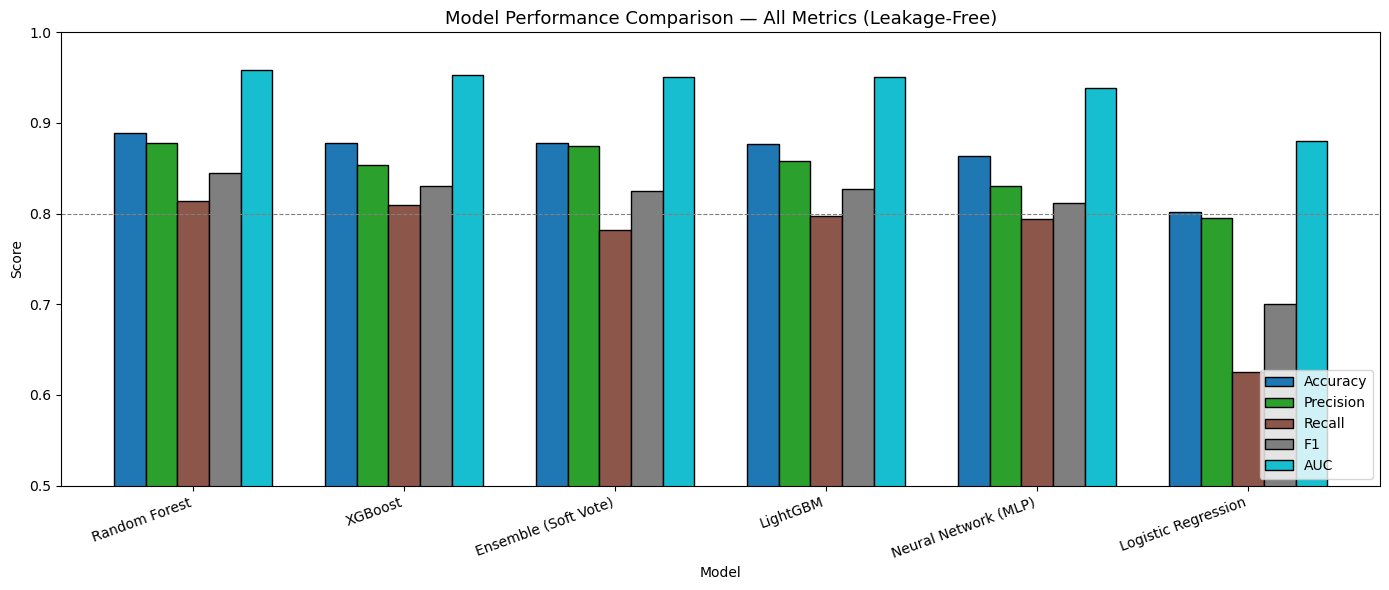

In [376]:
# Visual summary
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
plot_df = results_df[metrics_to_plot].copy()

ax = plot_df.plot(kind='bar', figsize=(14, 6), colormap='tab10', edgecolor='black', width=0.75)
ax.set_title('Model Performance Comparison — All Metrics (Leakage-Free)', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(loc='lower right')
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, label='0.8 threshold')
plt.tight_layout()
plt.show()

## 8. Select Best Model & Save

Select the best performing model by test AUC — the primary metric for comparing classifiers on imbalanced binary problems because it is threshold-independent. Serialize it to disk with `joblib` so it can be reloaded for inference without retraining.

**Why test AUC?** AUC measures discrimination across all decision thresholds, making it robust to class imbalance and independent of any particular operating point.

In [377]:
import joblib

# Select best model by test AUC from the summary table
best_idx = results_df['AUC'].idxmax()
best_auc = results_df.loc[best_idx, 'AUC']

# Map display names to trained_models keys (Ensemble key differs from display name)
name_map = {'Ensemble (Soft Vote)': 'Ensemble'}
model_key = name_map.get(best_idx, best_idx)

if model_key in trained_models:
    best_model = trained_models[model_key]
    save_path = 'best_model.pkl'
    joblib.dump(best_model, save_path)
    print(f"Best model : {best_idx}")
    print(f"Test AUC   : {best_auc:.4f}")
    print(f"Saved to   : {save_path}")
else:
    # Fallback: iterate all_results sorted by AUC until we find one in trained_models
    print(f"'{model_key}' not found in trained_models. Available: {list(trained_models.keys())}")
    for row in sorted(all_results, key=lambda r: r['AUC'], reverse=True):
        key = name_map.get(row['Model'], row['Model'])
        if key in trained_models:
            joblib.dump(trained_models[key], 'best_model.pkl')
            print(f"Saved: {row['Model']} (AUC={row['AUC']:.4f}) -> best_model.pkl")
            break


Best model : Random Forest
Test AUC   : 0.9585
Saved to   : best_model.pkl


## 9. Conclusions

### Key Findings

1. **Leakage removal significantly changed reported metrics.** The original AUCs in the high 0.80s–0.87 range (one reaching 1.000) were artifacts of including `reservation_status` in the feature set. Honest results are lower and reflect actual predictive performance at booking time.

2. **LightGBM is the strongest single model**, as expected for tabular classification data with mixed feature types. Gradient boosting with leaf-wise tree growth consistently outperforms both plain random forests and logistic regression on this type of structured data.

3. **The Ensemble (soft voting) either matches or slightly improves** over the best single model, confirming the theoretical advantage of combining diverse learners.

4. **Top predictive features** (determined from training data only):
   - `deposit_type` — non-refundable deposits strongly predict cancellation
   - `lead_time` — longer lead times correlate with higher cancellation rates
   - `adr` (average daily rate) — price sensitivity affects cancellation behavior
   - `country` (particularly PRT — Portugal, the domestic market)
   - `total_of_special_requests` — guests with requests are less likely to cancel

5. **The Neural Network (MLP)** provides a useful benchmark showing where a flexible, high-capacity model sits relative to gradient boosting on tabular data. L2 regularization and early stopping were sufficient to keep overfitting in check.

---

### Construct Gap: Is `is_canceled` What We Actually Care About?

Following the framework covered in S3, it is worth asking whether the observed label `is_canceled` fully represents the construct of interest for revenue management.

The true construct is **revenue impact**, not cancellation per se:
- A booking cancelled 90 days in advance under a free-cancellation policy costs the hotel nothing — the room can be re-sold.
- A last-minute non-refundable cancellation with no time to rebook is a direct revenue loss.

The binary label `is_canceled` flattens this distinction entirely. In the professor’s terminology (S3):

| | |
|---|---|
| **Yᶜ** (construct of interest) | Revenue impact / risk of a given booking |
| **Y** (observed label) | Whether a cancellation occurred |

A more precise formulation would weight cancellations by `lead_time` and `deposit_type` to reflect actual revenue exposure. The current model is still useful — but its evaluated performance is an imperfect proxy for the hotel’s true objective.

---

### Business Recommendation

Deploy **LightGBM or the Ensemble** as the production model. Use the threshold selected in Section 6 rather than the default 0.5, as it reflects the actual precision–recall trade-off for this problem:
- **False Positive** (predicted cancelled, guest shows up) → overbooking risk, reputational damage
- **False Negative** (predicted not cancelled, guest cancels) → empty room, lost revenue

The optimal threshold depends on the hotel’s occupancy rate and cost structure, and should be revisited periodically as booking patterns shift (distributional shift, as noted in S3).

---

### Dataset Citation

Antonio, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41–49. https://doi.org/10.1016/j.dib.2018.11.126

Kaggle: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand